# Oblique shocks and Prandtl-meyer expansions with Gaslab

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

from gaslab import GasState
from gaslab.plotting import theta_beta_m_figure, pressure_deflection_figure



© Tim Colonius, California Institute of Technology

Revised: July 11, 2023

Flow turning through an oblique shock or Prandtl-meyer exapnsion are invoked through the deflect process


![](../assets/notebook_image_oblique.png)

An planar oblique shock is shown above.

Analysis shows that the shock angle, $\beta$, is the solution of a nonlinear equation involving the deflection angle, $\theta$, and the upstream Mach number $M$.  The relation is

$ \tan\theta = 2 \cot\beta { ( M^2 \sin^2\beta- 1 ) 
 \over M^2(\gamma+\cos(2\beta))+2} $

Once the wave angle is determined, the solution for the downstream state follows from a normal shock analysis on the component of the flow normal to the oblique shock.  There are 0, 1, or 2 solutions for \beta for any given $\theta$ and $M$.  When there are 2 solutions, these are called the weak (small $\beta$) and strong (large $\beta$) solutions.

In gaslab, a weak oblique shock is invoked with the 'deflect' process.  For example, to deflect a M=2 air stream by 10 degrees through a weak oblique shock, we use

In [2]:
s = GasState.init(2, 1.4).deflect(10*np.pi/180)

We can use any of the properties queries on our new state, for example

In [25]:

print(s.mach)

1.640522229001081


The wave angle for an oblique shock is given byt he property 'shockang':

In [24]:
print(180*s.shockang/np.pi)

39.31


It is also added in the 'proc' property as a string

In [5]:
s.proc

'oblique shock (39.31 deg)'

We can visualize the oblique shock in the $\theta-\beta-M$ space with

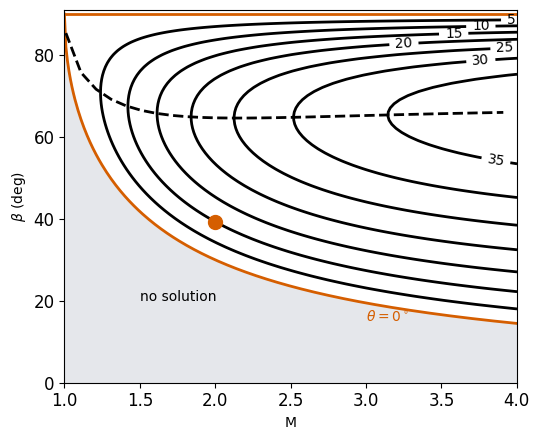

In [6]:
fig = theta_beta_m_figure(s)
fig

Notice in the plot that for M=2, there is no solution beyond about 22 degrees.  The maximum deflection angle where there is a single solution can be found using 'thetamax' query:

In [7]:
print(180*GasState.init(2, 1.4).thetamax/np.pi)


22.97353176093794


So if we try to deflect by more than 22.9735 degrees:

In [8]:
try:
    GasState.init(2, 1.4).deflect(30 * np.pi / 180)
except ValueError as exc:
    print(exc)


deflect: no oblique shock solution for the specified turn


The angle used in deflect is signed.  If we deflect the stream by -10 degrees, we will have a Prandtl-Meyer expansion rather than an oblique shock:

In [9]:
sexpand = GasState.init(2, 1.4).deflect(-10 * np.pi / 180)  # PM expansion
print(sexpand.proc)
print(sexpand.mach)

pm expansion
2.38488715459307


There is an optional 3rd argument to deflect, which is the wave family, which we label as +1 or -1 depending onthat whether the wave is compressing the flow (through an oblique shock) through a positive or negative angle, respectively (or, for a Prandtl-meyer expansion, whether the flow is expanded through a negative or positive angle, respectively). This is depicted in the sketch below.
![](../assets/notebook_image_family.png)


For many problems, the wave family can be omitted.

Thus each of the following produces the same state (apart from the flow angle):

In [10]:
s2a = GasState.init(2, 1.4).deflect(10*np.pi/180)
s2b = GasState.init(2, 1.4).deflect(10*np.pi/180, fam=1)
s2c = GasState.init(2, 1.4).deflect(-10*np.pi/180, fam=-1)


We can obtain the strong shock solution (rarely needed in solving problems), by using the optional 4th argument to deflect:

0.6036976431062597


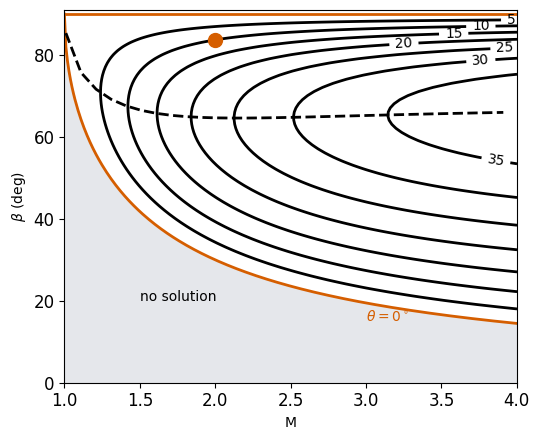

In [11]:
s3 = GasState.init(2, 1.4).deflect(10*np.pi/180, fam = 1,strong =True)
print(s3.mach)
fig2 = theta_beta_m_figure(s3)
fig2

Note that the regions where solutions exist is bounded by the $\theta =0$ deflection (red lines).  From below, the week solutions are bounded by the Mach angle, $\sin^{-1} {1 \over M}$.  From above, the strong solutions are bounded by the normal shock solution.  

Problem 1 (Anderson ex. 4.1): A uniform stream of air at $M_1 =3$ $p_1= 1$ atm, $T_1=288$K encounters a compression corner  that deflects the stream by $20^0$.  Calculate the shock wave angle, and $p_2$, $T_2$, $M_2$, $p_{02}$, and $T_{02}$ behind the shock wave.

In [12]:
os = GasState.init(3, 1.4, 1, 288, 28.96).deflect(np.pi * 20 / 180)
print(os.proc)
print(os.pres)
print(os.temp)
print(os.mach)
print(os.stagpres)
print(os.stagtemp)


oblique shock (37.76 deg)
3.7712574630826623
449.1697828666705
1.994131665564557
29.239917097772096
806.4


These answer differ by a few percent from Anderson's solution.  

In [13]:
os1 = GasState.init(3, 1.4, 1, 288, 28.96).deflect(np.pi*20/180, fam=1)
os2 = GasState.init(3, 1.4, 1, 288, 28.96).deflect(-np.pi*20/180, fam=-1)


Problem 2 (Under-expanded jet).  A supersonic air stream exits a planar CD nozzle at Mach 4 and expands to atmospheric pressure through a series of Prandtl-Meyer expansions and Oblique shocks (shock cells).  The situation near the nozzle exit depicted in the sketch.  

![](../assets/notebook_image_jet.png)

The ratio ${p_e\over p_a }= 10$. Find $M_d$ and $\theta_d$.

The key to this problem is understanding that in the region "d", the pressure must be matched with p_a across the slip line (vortex sheet).  Thus we want to find a P-M expansion from M_e through the angle \theta_d such that the downstream pressure decreases by 10.  Start by defining the exit state

In [14]:
exit_state = GasState.init(4, 1.4)


And make a function handle that returns the pressure ratio as a function of \theta_d:

In [15]:
prat = lambda ang: exit_state.pres / (exit_state.deflect(ang)).pres


Solve for ang where prat = 10:

In [16]:
ang = 180 * root_scalar(lambda ang: prat(ang) - 10, bracket=[-np.pi / 4, 0], method="brentq").root / np.pi
print(ang)

-18.906972953036405


Now that we know the angle, find the flow in region "d" and display information about it:

In [17]:
region_d = exit_state.deflect(np.pi*ang/180)
print(region_d.mach)
print(region_d.pres)

5.961933604674605
0.000658608730798865


Problem 3 (Lift and drag).  Consider a simple model of a supersonic airfoil in the form of a flat plate at an angle of attack $\alpha$.  For $M=3$, find and plot the lift and drag coefficients as a function of $0 < \alpha < 25^0$.

The force normal to the plate is $F_n = c (p_b - p_t )$ where c is the chord length.  Then normal force coefficient is then  $C_{N} = { F_{N} \over {1 \over 2} \rho_\infty U_\infty^2 c } = { 2 F_{N} \over \gamma p_\infty M^2 c} = { 2  \over \gamma M^2 } \left( { p_b \over p_\infty} - {p_t \over p_\infty} \right)$ and the lift and drag coefficients are $C_D = C_N \sin\alpha$, $C_L = C_N \cos\alpha$, respectively.  We just need to find the top and bottom pressure ratios.  Thus define the function

In [18]:
cn = lambda alf: (
    GasState.init(3, 1.4).deflect(alf).pres - GasState.init(3, 1.4).deflect(-alf).pres
) / GasState.init(3, 1.4).pres


For M=3 and air, we can plot

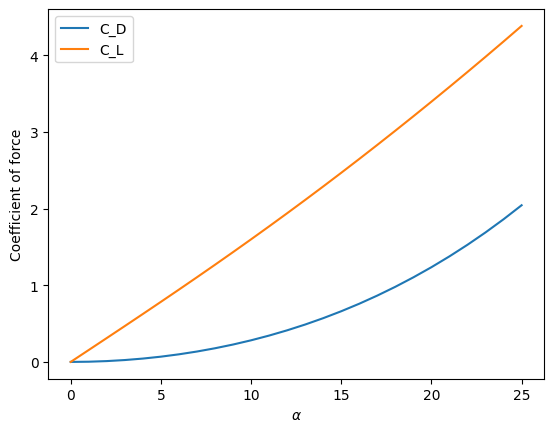

In [19]:
alfrange = np.pi * np.arange(0, 26, 1) / 180  # angles between 0 and 25 degrees
cn_vals = np.array([cn(a) for a in alfrange])
cd = np.sin(alfrange) * cn_vals
cl = np.cos(alfrange) * cn_vals
plt.figure()
plt.plot(180 * alfrange / np.pi, cd, label='C_D')
plt.plot(180 * alfrange / np.pi, cl, label='C_L')
plt.xlabel(r'$\alpha$')
plt.ylabel('Coefficient of force')
plt.legend()


Problem 4 (max deflection).  For air, make a plot of the deflection angle above which an oblique shock does not exist as a function of 0 < M < 4.

This problem can be solved directly by finding the thetamax property of states defined over the range of Mach numers:

Text(1.5, 30.0, 'No solution')

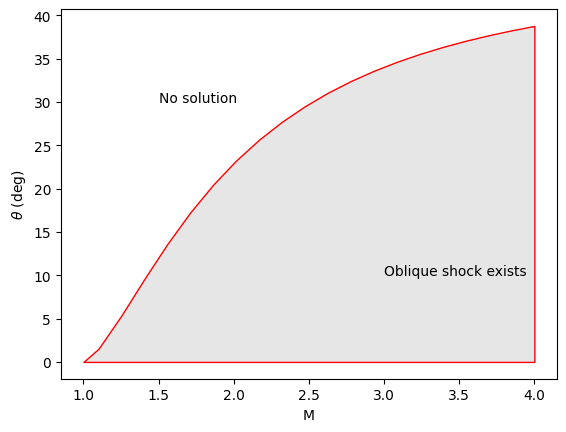

In [20]:
marange = np.linspace(1.1, 4, 20)
tmax = np.array([GasState.init(ma, 1.4).thetamax for ma in marange])
plt.fill_between(
    np.concatenate(([1], marange)),
    np.concatenate(([0], 180 * tmax / np.pi)),
    color='0.9',
    edgecolor='r',
)
plt.ylabel(r'$\theta$ (deg)')
plt.xlabel('M')
plt.text(3.0, 10.0, 'Oblique shock exists')
plt.text(1.5, 30.0, 'No solution')


Problem 5 (max deflection for regular reflection).  For air and the situation depicted in the sketch, if $M = 3$, find the maximum deflection angle $\theta$ above which the assumed regular reflection cannot occur.

The flow processed by the first shock needs to be turned through the same angle with an oblique shock of the opposite family.  However, it's Mach number is reduced by the first shock, and therefore the maximum deflection angle for which the reflected shock exists is reduced.  We can find the condition as "what deflection angle produces an OS shock with a downstream flow that has a thetamax equal to that deflection angle?

In [21]:
zerofun = lambda th: th - GasState.init(3, 1.4).deflect(th).thetamax
thmax = 180 * root_scalar(
    zerofun,
    x0=0.15,
    x1=0.2,
    method="secant",
).root / np.pi
print(thmax)

21.457804046903902


Pressure-deflection diagrams

Pressure-deflection diagrams are useful for visualizing the solutions to many problems related to shock reflection and transmission.  For a given state (1), the diagram plots the pressure, relative to state 1, of all states reachable through oblique shocks and Prandtl-meyer expansions.  For example, for air at M=3, we have

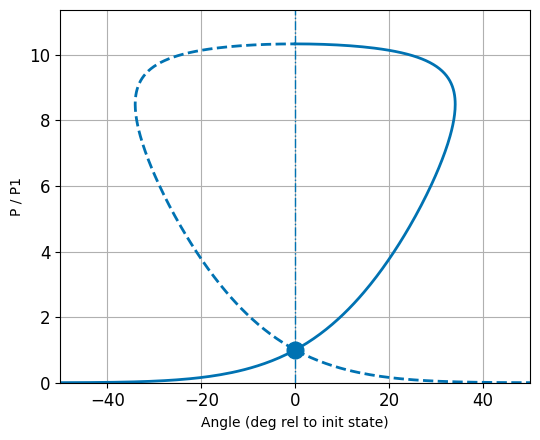

In [22]:
fig3 = pressure_deflection_figure(GasState.init(3,1.4))
fig3


The figure below shows the anatomy of the pressure-deflection diagram. 

![caption](../assets/notebook_image_pdef.png)

The diagram is especially useful for composite processes.  

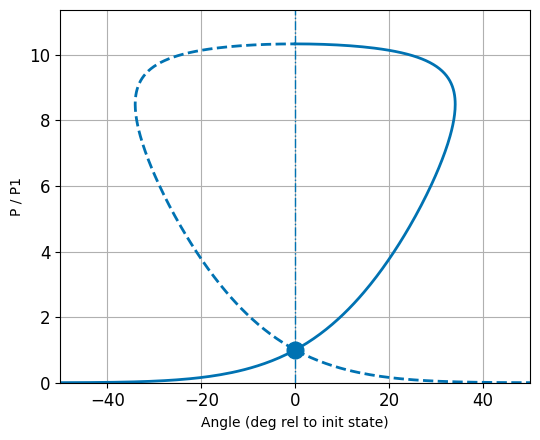

In [23]:
fig4 = pressure_deflection_figure(GasState.init(3,1.4))
fig4

